# World Cup 2026 Simulation
This will be with 3 models (the highest performing on validation data):
- Logistic Regression (n=10)
- XGBoost (n=10)
- XGBoost (n=20)

## Retrain Top 3 Models

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import StandardScaler

MODEL_DATA_DIR = Path('model_data')

N_VALUES = [5, 10, 15, 20]

FEATURES = [
    'elo_diff',
    'form_diff',
    'comp_form_diff'
]

def load_and_engineer(path):
    df = pd.read_csv(path)
    df['elo_diff']       = df['home_elo']       - df['away_elo']
    df['form_diff']      = df['home_form']       - df['away_form']
    df['comp_form_diff'] = df['home_comp_form']  - df['away_comp_form']
    return df


### Train Logistic Regression (n=10)

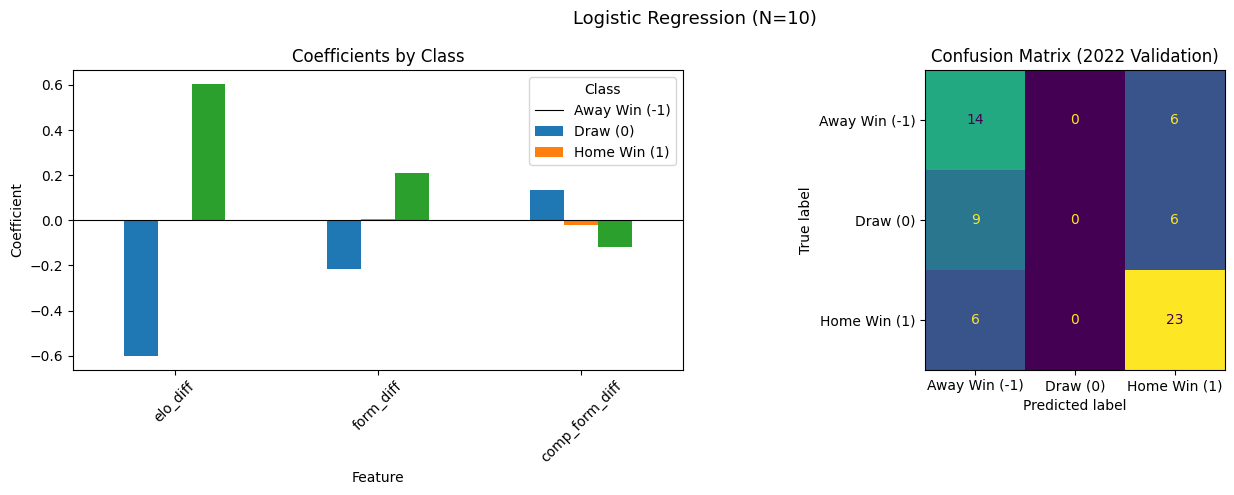

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

train = load_and_engineer(MODEL_DATA_DIR / 'training_data_10.csv')
val   = load_and_engineer(MODEL_DATA_DIR / 'validation_data_10.csv')

scaler = StandardScaler()
X_train = scaler.fit_transform(train[FEATURES])
X_val   = scaler.transform(val[FEATURES])
y_train, y_val = train['result'], val['result']

lr_best = LogisticRegression(random_state=42, max_iter=1000)
lr_best.fit(X_train, y_train)

LABELS = ['Away Win (-1)', 'Draw (0)', 'Home Win (1)']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression (N=10)', fontsize=13)

# Coefficient bar chart — one set of coefficients per class
coef_df = pd.DataFrame(lr_best.coef_, columns=FEATURES, index=lr_best.classes_)
coef_df.T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Coefficients by Class')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Coefficient')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Class', labels=LABELS)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, lr_best.predict(X_val),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

### Train XGBoost (n=10, 20)

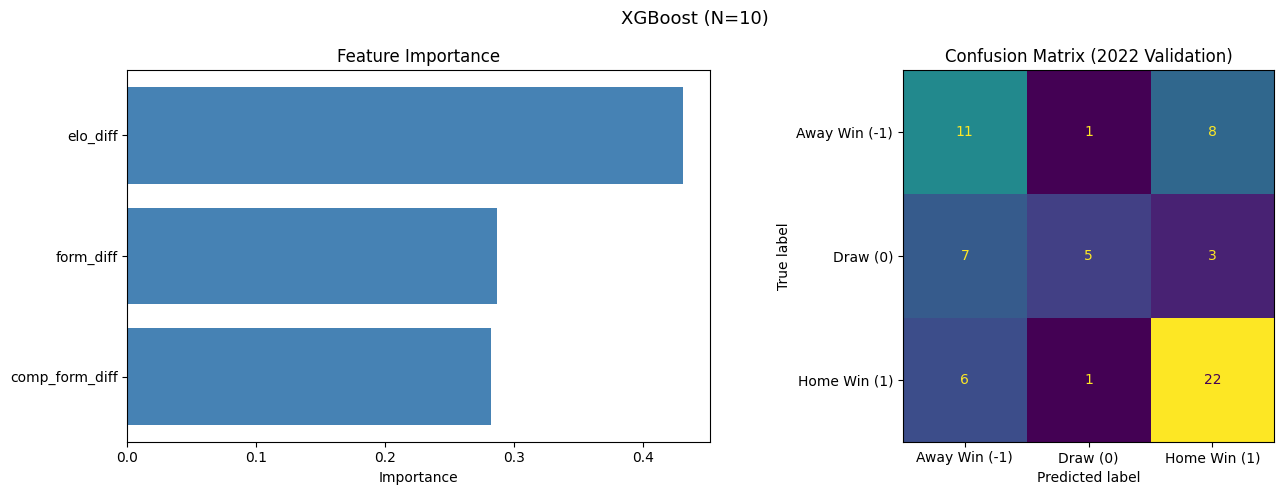

In [10]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

xgb_results = []

# Encode labels to 0,1,2 as XGBoost requires non-negative integer classes
le = LabelEncoder()

X_train, y_train = train[FEATURES].values, le.fit_transform(train['result'].values) # type: ignore
X_val,   y_val   = val[FEATURES].values,   le.transform(val['result'].values) # type: ignore

xgb_best_10 = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, reg_lambda=2.0,
    random_state=42, eval_metric='mlogloss', verbosity=0,
)
xgb_best_10.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost (N=10)', fontsize=13)

# Feature importance
axes[0].barh(FEATURES, xgb_best_10.feature_importances_, color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Confusion matrix — decode labels back to -1/0/1 for display
ConfusionMatrixDisplay.from_predictions(
    le.inverse_transform(y_val), le.inverse_transform(xgb_best_10.predict(X_val)),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

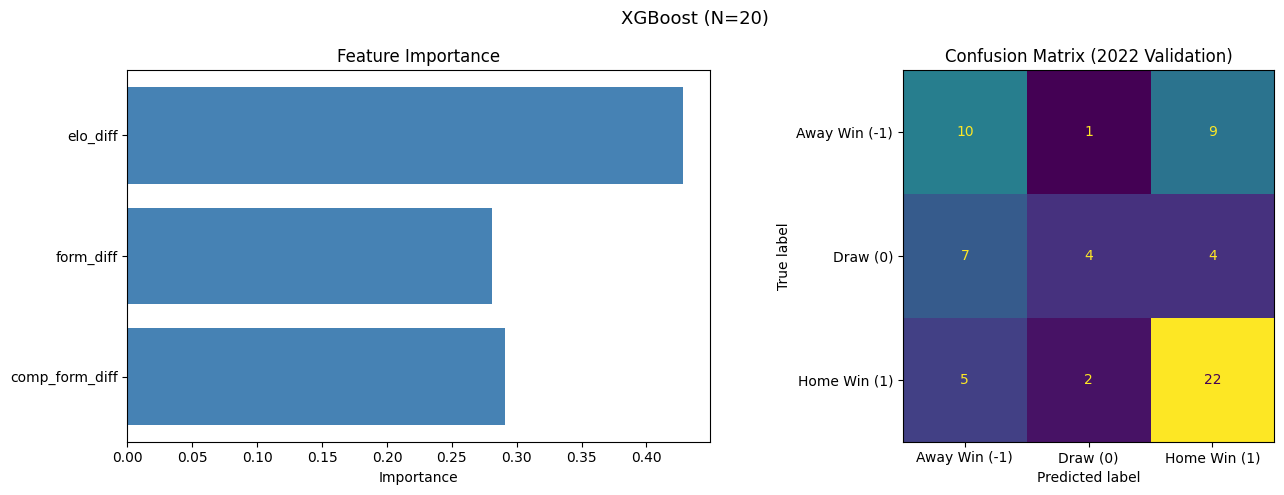

In [11]:
train = load_and_engineer(MODEL_DATA_DIR / 'training_data_20.csv')
val   = load_and_engineer(MODEL_DATA_DIR / 'validation_data_20.csv')

X_train, y_train = train[FEATURES].values, le.fit_transform(train['result'].values)
X_val,   y_val   = val[FEATURES].values,   le.transform(val['result'].values)

xgb_best_20 = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, reg_lambda=2.0,
    random_state=42, eval_metric='mlogloss', verbosity=0,
)
xgb_best_20.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost (N=20)', fontsize=13)

# Feature importance
axes[0].barh(FEATURES, xgb_best_20.feature_importances_, color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Confusion matrix — decode labels back to -1/0/1 for display
ConfusionMatrixDisplay.from_predictions(
    le.inverse_transform(y_val), le.inverse_transform(xgb_best_20.predict(X_val)),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

## Logistic Regression n=10 World Cup Model Predictions

In [12]:
import random

N_SIMS = 10_000

fixtures_lr = pd.read_csv(MODEL_DATA_DIR / 'fixtures_2026_n10.csv')

# Get model probabilities for each fixture — classes are [-1, 0, 1]
X_fixtures = scaler.transform(fixtures_lr[FEATURES].values)
probs_lr = lr_best.predict_proba(X_fixtures)  # shape (72, 3), columns = [-1, 0, 1]
classes = list(lr_best.classes_)              # [-1, 0, 1]

# Attach probs to fixtures for easy lookup
fixtures_lr['p_away'] = probs_lr[:, classes.index(-1)]
fixtures_lr['p_draw'] = probs_lr[:, classes.index(0)]
fixtures_lr['p_home'] = probs_lr[:, classes.index(1)]

GROUPS = sorted(fixtures_lr['group'].unique())

# Accumulate points per team per simulation
sim_points = {g: {} for g in GROUPS}
for g in GROUPS:
    teams = pd.unique(fixtures_lr[fixtures_lr['group'] == g][['home_team', 'away_team']].values.ravel())
    sim_points[g] = {t: np.zeros(N_SIMS) for t in teams}

for sim in range(N_SIMS):
    for _, row in fixtures_lr.iterrows():
        outcome = random.choices([-1, 0, 1], weights=[row['p_away'], row['p_draw'], row['p_home']])[0]
        if outcome == 1:    # home win
            sim_points[row['group']][row['home_team']][sim] += 3
        elif outcome == -1: # away win
            sim_points[row['group']][row['away_team']][sim] += 3
        else:               # draw
            sim_points[row['group']][row['home_team']][sim] += 1
            sim_points[row['group']][row['away_team']][sim] += 1

# Average expected points across simulations
print('=== Logistic Regression (N=10) — Expected Group Points ===\n')
group_tables_lr = {}
for g in GROUPS:
    rows = [{'team': t, 'expected_pts': round(float(np.mean(pts)), 2)}
            for t, pts in sim_points[g].items()]
    table = pd.DataFrame(rows).sort_values('expected_pts', ascending=False).reset_index(drop=True)
    table.index += 1
    group_tables_lr[g] = table
    print(f'Group {g}')
    print(table.to_string())
    print()

/Users/stefanilic/Documents/GitHub/world-cup-predictions/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


=== Logistic Regression (N=10) — Expected Group Points ===

Group A
             team  expected_pts
1          Mexico          5.43
2     South Korea          4.79
3  Czech Republic          4.19
4    South Africa          2.10

Group B
                     team  expected_pts
1             Switzerland          6.79
2                  Canada          5.63
3  Bosnia and Herzegovina          3.11
4                   Qatar          1.28

Group C
       team  expected_pts
1    Brazil          5.90
2   Morocco          4.75
3  Scotland          3.97
4     Haiti          1.94

Group D
            team  expected_pts
1         Turkey          5.84
2  United States          3.74
3       Paraguay          3.62
4      Australia          3.22

Group E
          team  expected_pts
1      Germany          6.22
2      Ecuador          6.04
3  Ivory Coast          3.20
4      Curaçao          1.32

Group F
          team  expected_pts
1  Netherlands          5.95
2        Japan          5.84
3       Sw

### Visualize groups and see who moves on to knockouts

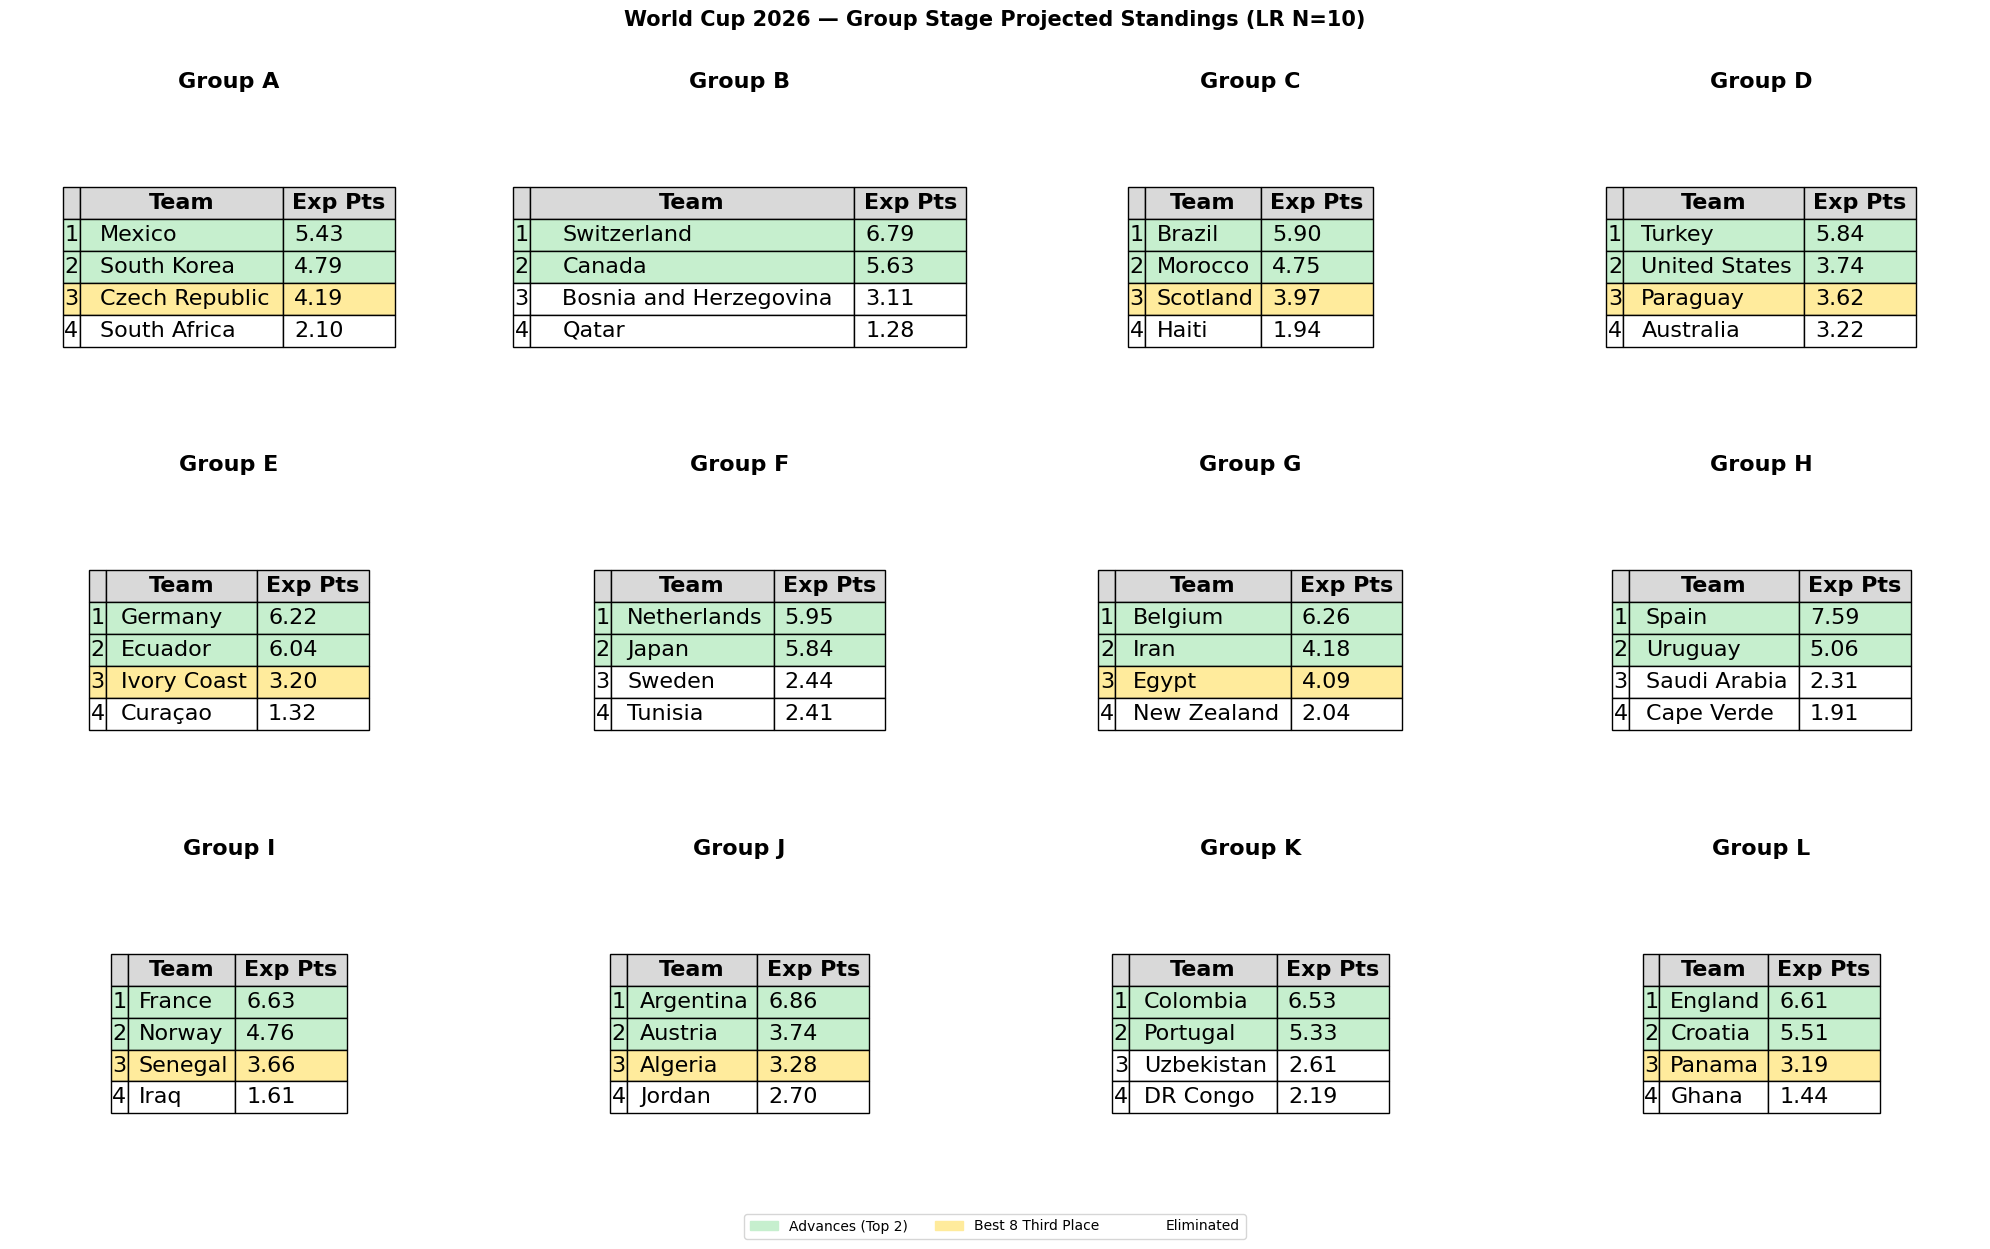

In [19]:
import matplotlib.patches as mpatches

# Find the 3rd place team from each group and rank them
third_place = []
for g, table in group_tables_lr.items():
    row = table.iloc[2]
    third_place.append({'group': g, 'team': row['team'], 'expected_pts': row['expected_pts']})

third_place_df = pd.DataFrame(third_place).sort_values('expected_pts', ascending=False).reset_index(drop=True)
best_8_third = set(third_place_df.head(8)['team'])

COLOR_GREEN  = '#c6efce'
COLOR_YELLOW = '#ffeb9c'
COLOR_WHITE  = '#ffffff'
COLOR_GRAY   = '#d9d9d9'

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('World Cup 2026 — Group Stage Projected Standings (LR N=10)', fontsize=15, fontweight='bold', y=1.01)

for idx, g in enumerate(GROUPS):
    ax = axes[idx // 4][idx % 4]
    ax.axis('off')
    ax.set_title(f'Group {g}', fontweight='bold', fontsize=16, pad=4)

    table = group_tables_lr[g]
    cell_text, cell_colors = [], []

    for rank, row in table.iterrows():
        team, pts = row['team'], row['expected_pts']
        if rank <= 2:
            bg = COLOR_GREEN
        elif team in best_8_third:
            bg = COLOR_YELLOW
        else:
            bg = COLOR_WHITE
        cell_text.append([str(rank), team, f'{pts:.2f}'])
        cell_colors.append([bg, bg, bg])

    tbl = ax.table(
        cellText=cell_text,
        colLabels=['', 'Team', 'Exp Pts'],
        cellColours=cell_colors,
        cellLoc='left',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(16)
    tbl.scale(1, 1.5)
    for j in range(3):
        tbl[(0, j)].set_text_props(fontweight='bold')
        tbl[(0, j)].set_facecolor(COLOR_GRAY)
    tbl.auto_set_column_width([0, 1, 2])

legend_patches = [
    mpatches.Patch(color=COLOR_GREEN,  label='Advances (Top 2)'),
    mpatches.Patch(color=COLOR_YELLOW, label='Best 8 Third Place'),
    mpatches.Patch(color=COLOR_WHITE,  label='Eliminated'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

---
## XGBoost (n=10)

In [20]:
fixtures_xgb10 = pd.read_csv(MODEL_DATA_DIR / 'fixtures_2026_n10.csv')

X_fixtures_xgb10 = fixtures_xgb10[FEATURES].values
probs_xgb10 = xgb_best_10.predict_proba(X_fixtures_xgb10)  # classes encoded: 0=-1, 1=0, 2=1
xgb_classes = list(le.classes_)  # [-1, 0, 1]

fixtures_xgb10['p_away'] = probs_xgb10[:, xgb_classes.index(-1)]
fixtures_xgb10['p_draw'] = probs_xgb10[:, xgb_classes.index(0)]
fixtures_xgb10['p_home'] = probs_xgb10[:, xgb_classes.index(1)]

sim_points_xgb10 = {g: {} for g in GROUPS}
for g in GROUPS:
    teams = pd.unique(fixtures_xgb10[fixtures_xgb10['group'] == g][['home_team', 'away_team']].values.ravel())
    sim_points_xgb10[g] = {t: np.zeros(N_SIMS) for t in teams}

for sim in range(N_SIMS):
    for _, row in fixtures_xgb10.iterrows():
        outcome = random.choices([-1, 0, 1], weights=[row['p_away'], row['p_draw'], row['p_home']])[0]
        if outcome == 1:
            sim_points_xgb10[row['group']][row['home_team']][sim] += 3
        elif outcome == -1:
            sim_points_xgb10[row['group']][row['away_team']][sim] += 3
        else:
            sim_points_xgb10[row['group']][row['home_team']][sim] += 1
            sim_points_xgb10[row['group']][row['away_team']][sim] += 1

group_tables_xgb10 = {}
for g in GROUPS:
    rows = [{'team': t, 'expected_pts': round(float(np.mean(pts)), 2)}
            for t, pts in sim_points_xgb10[g].items()]
    table = pd.DataFrame(rows).sort_values('expected_pts', ascending=False).reset_index(drop=True)
    table.index += 1
    group_tables_xgb10[g] = table

print('XGBoost N=10 done.')

XGBoost N=10 done.


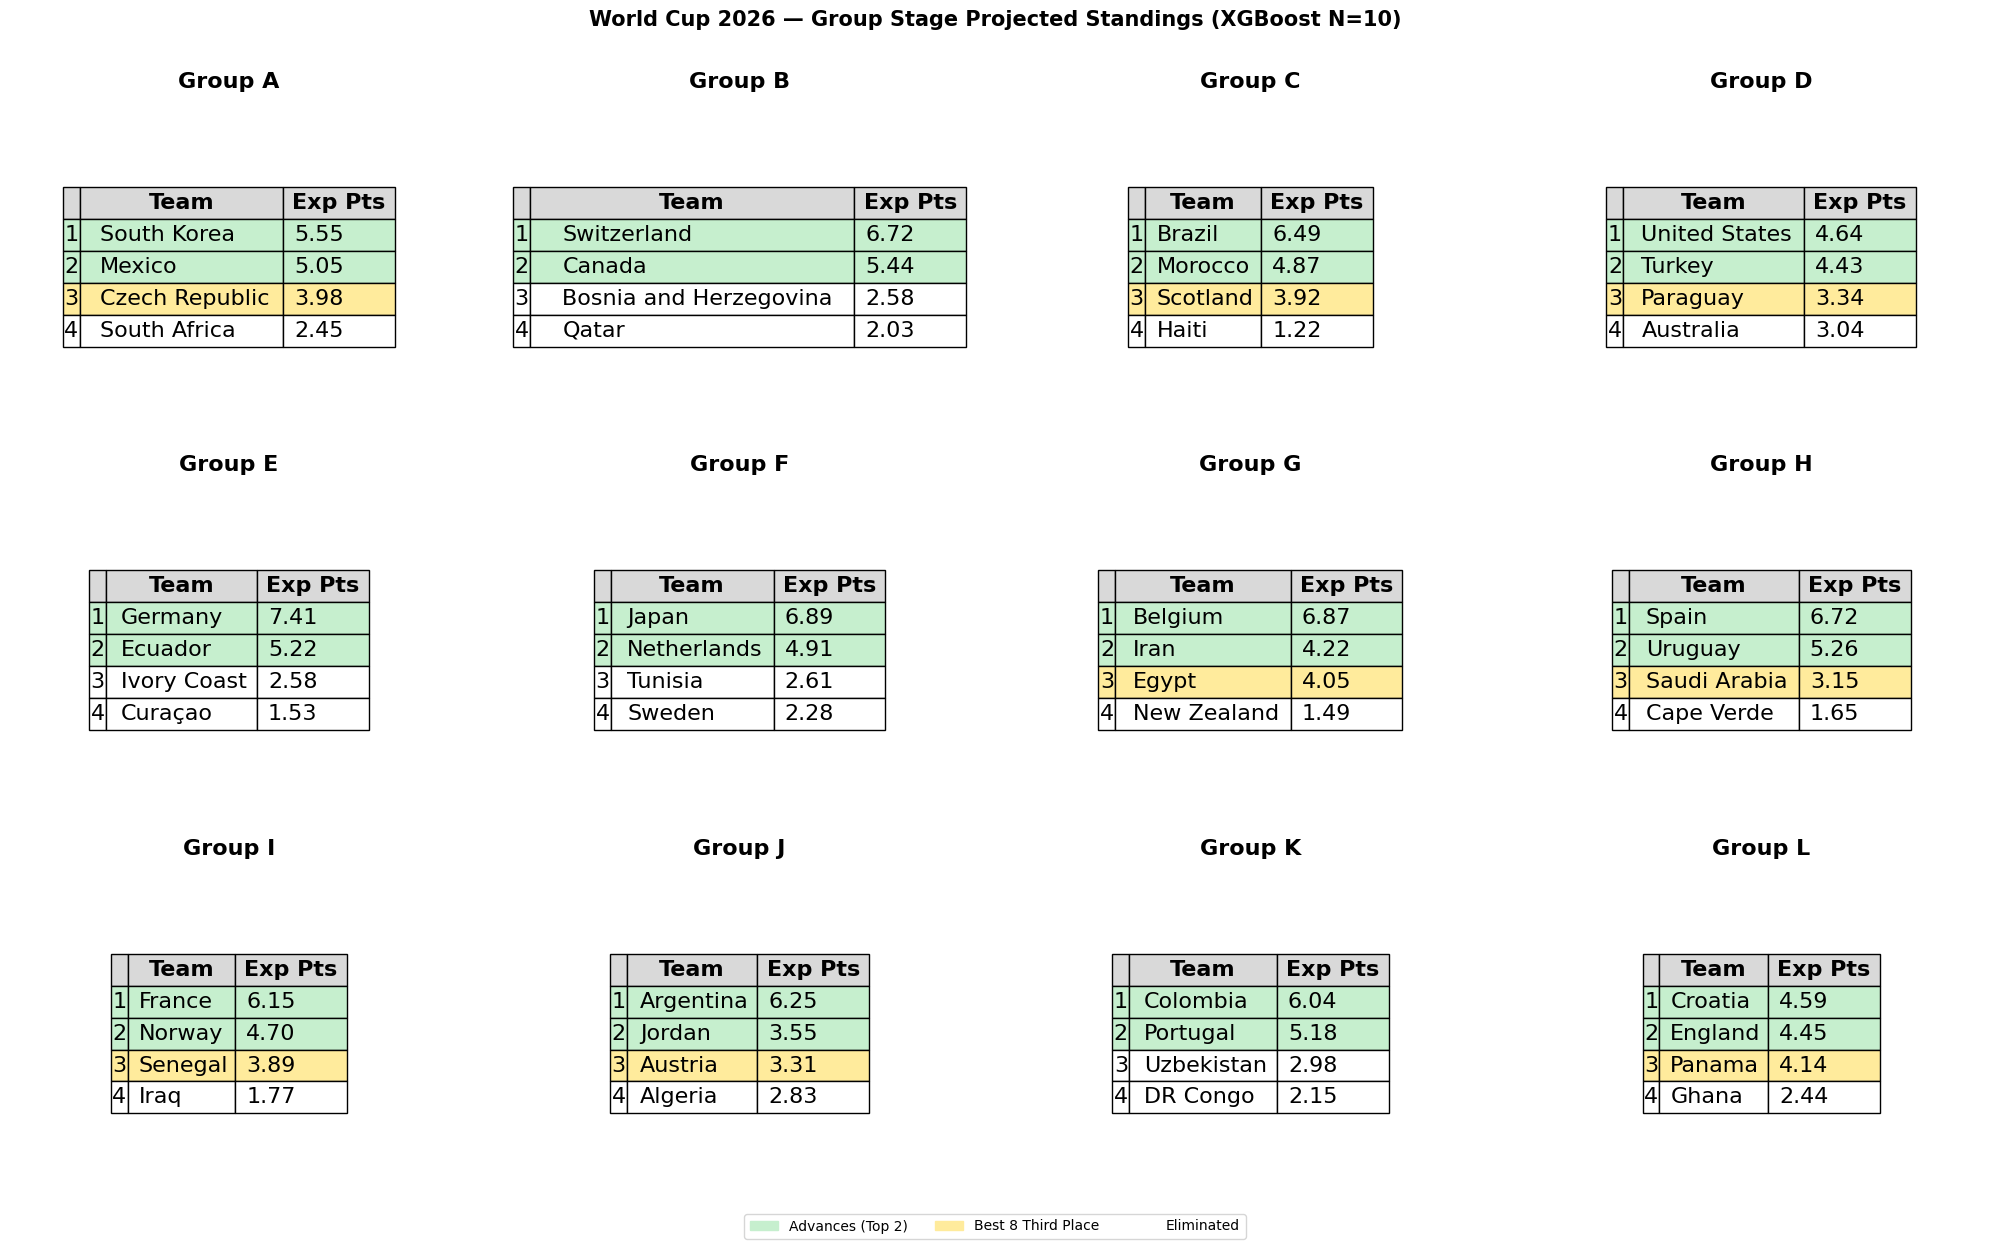

In [21]:
third_place = []
for g, table in group_tables_xgb10.items():
    row = table.iloc[2]
    third_place.append({'group': g, 'team': row['team'], 'expected_pts': row['expected_pts']})
best_8_third_xgb10 = set(pd.DataFrame(third_place).sort_values('expected_pts', ascending=False).head(8)['team'])

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('World Cup 2026 — Group Stage Projected Standings (XGBoost N=10)', fontsize=15, fontweight='bold', y=1.01)

for idx, g in enumerate(GROUPS):
    ax = axes[idx // 4][idx % 4]
    ax.axis('off')
    ax.set_title(f'Group {g}', fontweight='bold', fontsize=16, pad=4)

    table = group_tables_xgb10[g]
    cell_text, cell_colors = [], []

    for rank, row in table.iterrows():
        team, pts = row['team'], row['expected_pts']
        if rank <= 2:             bg = COLOR_GREEN
        elif team in best_8_third_xgb10: bg = COLOR_YELLOW
        else:                     bg = COLOR_WHITE
        cell_text.append([str(rank), team, f'{pts:.2f}'])
        cell_colors.append([bg, bg, bg])

    tbl = ax.table(cellText=cell_text, colLabels=['', 'Team', 'Exp Pts'],
                   cellColours=cell_colors, cellLoc='left', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(16)
    tbl.scale(1, 1.5)
    for j in range(3):
        tbl[(0, j)].set_text_props(fontweight='bold')
        tbl[(0, j)].set_facecolor(COLOR_GRAY)
    tbl.auto_set_column_width([0, 1, 2])

legend_patches = [
    mpatches.Patch(color=COLOR_GREEN,  label='Advances (Top 2)'),
    mpatches.Patch(color=COLOR_YELLOW, label='Best 8 Third Place'),
    mpatches.Patch(color=COLOR_WHITE,  label='Eliminated'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

---
## XGBoost (n=20)

In [24]:
fixtures_xgb20 = pd.read_csv(MODEL_DATA_DIR / 'fixtures_2026_n20.csv')

X_fixtures_xgb20 = fixtures_xgb20[FEATURES].values
probs_xgb20 = xgb_best_20.predict_proba(X_fixtures_xgb20)

fixtures_xgb20['p_away'] = probs_xgb20[:, xgb_classes.index(-1)]
fixtures_xgb20['p_draw'] = probs_xgb20[:, xgb_classes.index(0)]
fixtures_xgb20['p_home'] = probs_xgb20[:, xgb_classes.index(1)]

sim_points_xgb20 = {g: {} for g in GROUPS}
for g in GROUPS:
    teams = pd.unique(fixtures_xgb20[fixtures_xgb20['group'] == g][['home_team', 'away_team']].values.ravel())
    sim_points_xgb20[g] = {t: np.zeros(N_SIMS) for t in teams}

for sim in range(N_SIMS):
    for _, row in fixtures_xgb20.iterrows():
        outcome = random.choices([-1, 0, 1], weights=[row['p_away'], row['p_draw'], row['p_home']])[0]
        if outcome == 1:
            sim_points_xgb20[row['group']][row['home_team']][sim] += 3
        elif outcome == -1:
            sim_points_xgb20[row['group']][row['away_team']][sim] += 3
        else:
            sim_points_xgb20[row['group']][row['home_team']][sim] += 1
            sim_points_xgb20[row['group']][row['away_team']][sim] += 1

group_tables_xgb20 = {}
for g in GROUPS:
    rows = [{'team': t, 'expected_pts': round(float(np.mean(pts)), 2)}
            for t, pts in sim_points_xgb20[g].items()]
    table = pd.DataFrame(rows).sort_values('expected_pts', ascending=False).reset_index(drop=True)
    table.index += 1
    group_tables_xgb20[g] = table

print('XGBoost N=20 done.')

XGBoost N=20 done.


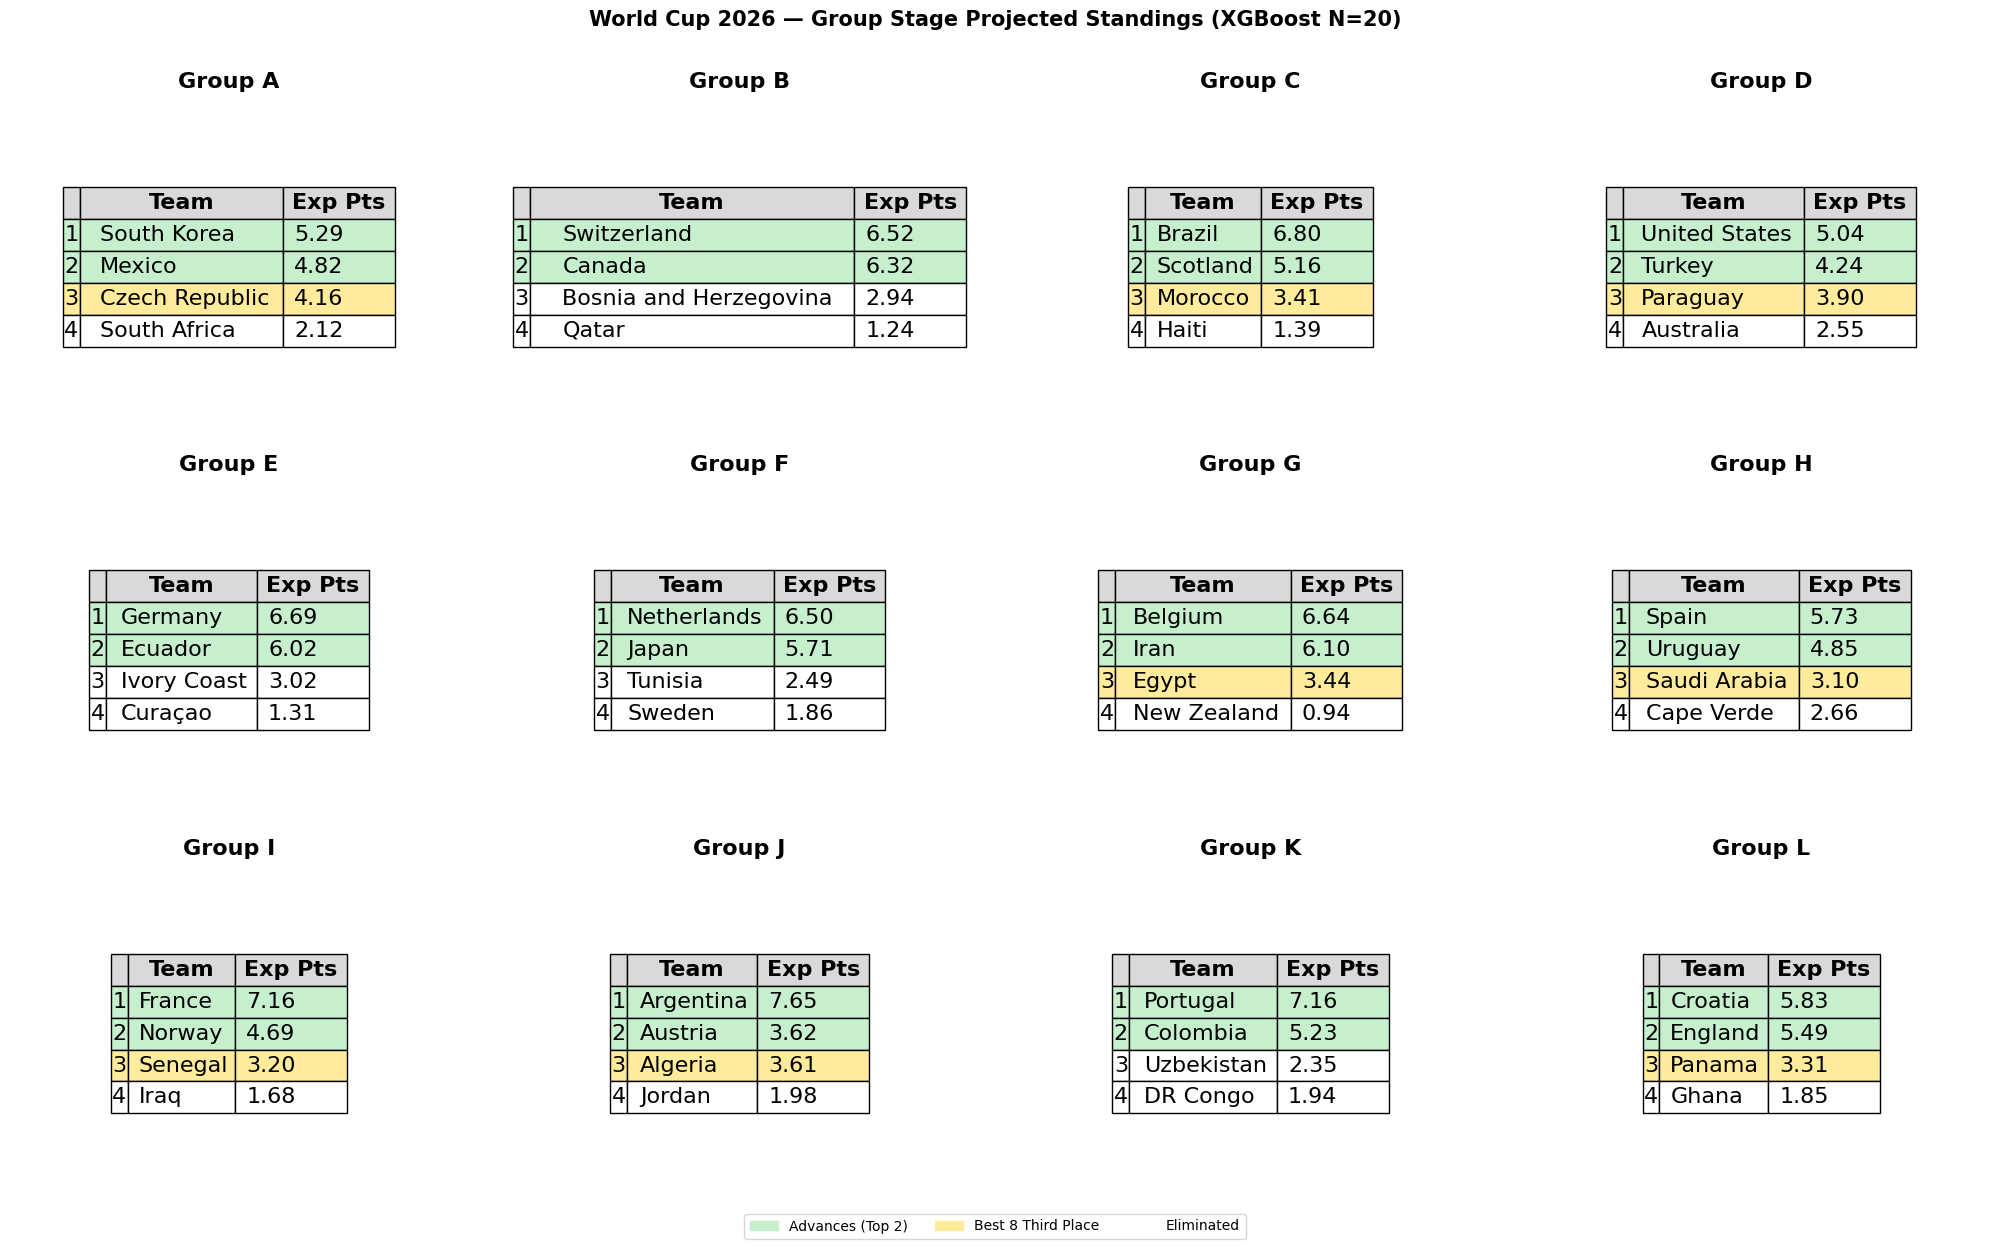

In [25]:
third_place = []
for g, table in group_tables_xgb20.items():
    row = table.iloc[2]
    third_place.append({'group': g, 'team': row['team'], 'expected_pts': row['expected_pts']})
best_8_third_xgb20 = set(pd.DataFrame(third_place).sort_values('expected_pts', ascending=False).head(8)['team'])

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('World Cup 2026 — Group Stage Projected Standings (XGBoost N=20)', fontsize=15, fontweight='bold', y=1.01)

for idx, g in enumerate(GROUPS):
    ax = axes[idx // 4][idx % 4]
    ax.axis('off')
    ax.set_title(f'Group {g}', fontweight='bold', fontsize=16, pad=4)

    table = group_tables_xgb20[g]
    cell_text, cell_colors = [], []

    for rank, row in table.iterrows():
        team, pts = row['team'], row['expected_pts']
        if rank <= 2:                    bg = COLOR_GREEN
        elif team in best_8_third_xgb20: bg = COLOR_YELLOW
        else:                            bg = COLOR_WHITE
        cell_text.append([str(rank), team, f'{pts:.2f}'])
        cell_colors.append([bg, bg, bg])

    tbl = ax.table(cellText=cell_text, colLabels=['', 'Team', 'Exp Pts'],
                   cellColours=cell_colors, cellLoc='left', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(16)
    tbl.scale(1, 1.5)
    for j in range(3):
        tbl[(0, j)].set_text_props(fontweight='bold')
        tbl[(0, j)].set_facecolor(COLOR_GRAY)
    tbl.auto_set_column_width([0, 1, 2])

legend_patches = [
    mpatches.Patch(color=COLOR_GREEN,  label='Advances (Top 2)'),
    mpatches.Patch(color=COLOR_YELLOW, label='Best 8 Third Place'),
    mpatches.Patch(color=COLOR_WHITE,  label='Eliminated'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()